The Hubbard model captures two competing physical processes:

- Electron hopping between neighboring lattice sites  
- On-site Coulomb repulsion between electrons occupying the same site  

The Hubbard Hamiltonian is given by

$$
H = -t \sum_{\langle i,j \rangle,\sigma}
\left(
c^{\dagger}_{i\sigma} c_{j\sigma}
+
c^{\dagger}_{j\sigma} c_{i\sigma}
\right)
+
U \sum_i n_{i\uparrow} n_{i\downarrow}
$$

where:

- $t$ is the hopping amplitude between neighboring lattice sites  
- $U$ is the on-site interaction strength  
- $c^{\dagger}_{i\sigma}$ and $c_{i\sigma}$ are fermionic creation and annihilation operators  
- $n_{i\sigma} = c^{\dagger}_{i\sigma} c_{i\sigma}$ is the number operator  
- $\sigma \in \{\uparrow, \downarrow\}$ denotes the electron spin  

In [1]:
import netket as nk
import netket.experimental as nkx
import numpy as np
from flax import nnx
from netket.utils import struct
from netket.sampler.rules import ExchangeRule
from netket.hilbert import SpinOrbitalFermions
import os

pbc = [True, True]

L_x = 4
L_y = 4
N_up = N_down = 7

hilb = nk.hilbert.SpinOrbitalFermions(
    n_orbitals= L_x * L_y, s=1/2, n_fermions_per_spin=(N_up, N_down)
)

t = 1
U = 8

def c(site, sz):
    return nk.operator.fermion.destroy(hilb, site, sz=sz)


def cdag(site, sz):
    return nk.operator.fermion.create(hilb, site, sz=sz)


def nc(site, sz):
    return nk.operator.fermion.number(hilb, site, sz=sz)

g = nk.graph.Grid(extent=[L_x, L_y], pbc=pbc)

up = +1
down = -1
ham = 0.0

for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) @ c(v, sz) - t * cdag(v, sz) @ c(u, sz)
for u in g.nodes():
    ham += U * nc(u, up) @ nc(u, down)


H8 = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(
    ham
)

∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

## Hidden Fermion Approach

First, we employ the **hidden fermion approach** introduced in the article

> Javier Robledo Moreno, Giuseppe Carleo, Antoine Georges, and James Stokes,  
> *Fermionic wave functions from neural-network constrained hidden states*,  
> PNAS **119**, e2122059119 (2022).

### Reference

- Open-access PNAS article:  
  [PNAS Publication](https://www.pnas.org/doi/10.1073/pnas.2122059119?utm_source=chatgpt.com)

- Open-access arXiv preprint:  
  [arXiv:2111.10420](https://arxiv.org/abs/2111.10420?utm_source=chatgpt.com)

This method introduces additional hidden fermionic degrees of freedom
to construct highly expressive variational wave functions for strongly
correlated quantum systems such as the Hubbard model.

The central idea is to extend the physical Hilbert space by auxiliary
(hidden) fermions and then project the resulting Slater determinant
back onto the physical space using a neural-network-parameterized
constraint.

The variational wave function can schematically be written as

$$
\psi(x)
=
\det \Phi(x, h(x))
$$

where:

- $x$ denotes the visible fermionic configuration  
- $h(x)$ represents hidden fermionic degrees of freedom  
- $\Phi$ is the augmented Slater matrix containing both visible and hidden orbitals  

This construction provides a systematically improvable ansatz with high
expressive power for strongly correlated fermionic systems.

In [2]:
import jax
import jax
import jax.numpy as jnp

# jax.config.update("jax_enable_x64", False)

def _logdet_cmplx(A, eps=5e-2):
    # Stable logdet
    eps_eye = eps * jnp.eye(A.shape[0], dtype=A.dtype)
    sign, logabsdet = jnp.linalg.slogdet(A + eps_eye)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))


class LogHiddenFermion(nnx.Module):
    hilbert: "nk.hilbert.SpinOrbitalFermions"

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        n_hidden_fermions: int,
        rngs: nnx.Rngs,
        kernel_init=nnx.initializers.lecun_normal(),
        activation=nnx.relu,
        n_layers=1,
        eps=2e-1,
        tiny_init_std=0.0001,
    ):
        self.eps = eps
        self.hilbert = hilbert
        L = hilbert.n_orbitals

        Nup, Ndown = hilbert.n_fermions_per_spin
        Nfull = Nup + Ndown
        NHFfull = n_hidden_fermions
        
        key_full, key_bf1, key_bf4 = jax.random.split(rngs.params(), 3)

        self.M_full = nnx.Param(kernel_init(key_full, (2 * L, Nfull + NHFfull))) 

        tiny_init = nnx.initializers.normal(stddev=tiny_init_std)
        layers = [
            nnx.Linear(
                in_features=2 * L,
                out_features= NHFfull * hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            lambda x: x.reshape(
                x.shape[:-1] + (NHFfull, hidden_units)
            )]
        for _ in range(n_layers - 1):
            layers += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=Nfull + NHFfull,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet = nnx.Sequential(*layers
        )


    def __call__(self, n: jax.Array) -> jax.Array:
        def log_sd(ncfg):
            L = self.hilbert.n_orbitals
            Nall= self.hilbert.n_fermions

            R_full = ncfg.nonzero(size=Nall)[0]
            F_full = self.neuralNet(ncfg)
            A_full = jnp.concatenate([self.M_full[R_full], F_full], axis=0)
            
            ret = _logdet_cmplx(A_full, eps=self.eps)
            return ret

        if n.ndim == 1:
            return log_sd(n)
        return jax.vmap(log_sd)(n)


def count_params(module):
    leaves = jax.tree_util.tree_leaves(nnx.state(module, nnx.Param))
    return sum(x.size for x in leaves)
    

In [3]:
alpha = 6
n_hidden_fermions = 14
n_layers = 1

n_hidden = alpha * (hilb.n_orbitals * 2)

lr = 0.03
diag_shift = 0.01

n_samples = 2048
n_steps = 5000
chunk_size = 512

rngs = nnx.Rngs(jax.random.PRNGKey(0))
ma8 = LogHiddenFermion(hilb, rngs=rngs, hidden_units=n_hidden, n_hidden_fermions=n_hidden_fermions, n_layers=n_layers) #, activation=nnx.tanh)
sa8 = nk.sampler.MetropolisFermionHop(hilb, graph=g,
                                      n_chains=16,
                                      sweep_size=4*hilb.n_orbitals)
vs_hf = nk.vqs.MCState(sa8, ma8, n_samples=n_samples, chunk_size=chunk_size)

print("hidden units:", n_hidden)
print("hidden fermions:", n_hidden_fermions)
print("n_layers:", n_layers)
print("WF parameters:", count_params(ma8))

optE = nk.optimizer.Sgd(learning_rate=lr)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_hf, diag_shift=diag_shift, mode="real")

lfile = "Training_nets_pbc_"+str(n_hidden)+"hf"+str(n_hidden_fermions)+"_layers"+str(n_layers)
try:
    import flax
    with open(lfile + ".mpack", 'rb') as file:
        vs_hf.variables = flax.serialization.from_bytes(vs_hf.variables, file.read())
    print("Loaded parameters from file:", lfile + ".mpack")
except Exception as e:
    gs8.run(n_steps, out=lfile)

hidden units: 192
hidden fermions: 14
n_layers: 1
WF parameters: 95004
Automatic SR implementation choice:  NTK
Loaded parameters from file: Training_nets_pbc_192hf14_layers1.mpack


In [4]:
vs_hf.expect(H8)

-11.760+0.000j ± 0.015 [σ²=4.6e-01, R̂=1.005]

## Pfaffian Neural-Network Ansatz

Next, we employ a **Pfaffian-based variational ansatz** inspired by the recent work

> *Neural Pfaffians for Correlated Fermionic Quantum Systems* (2025)

### Reference

- arXiv preprint:  
  [arXiv:2507.10705](https://arxiv.org/abs/2507.10705)

Pfaffian wave functions provide a natural generalization of Slater
determinants and are particularly well suited for describing
pair-correlated fermionic states. In contrast to a determinant-based
ansatz, the Pfaffian formulation can efficiently encode pairing
correlations and superconducting structures.

The variational wave function is written as

$$
\psi(x)
=
\mathrm{Pf}\!\left(F(x)\right)
$$

where:

- $x$ denotes the fermionic configuration  
- $F(x)$ is an antisymmetric pairing matrix  
- $\mathrm{Pf}$ denotes the Pfaffian of the matrix  

In our implementation, the pairing matrix is parameterized using a very
simple neural-network architecture consisting of a single fully connected
(dense) layer. The neural network maps the fermionic occupation
configuration to effective pairing amplitudes,

$$
F(x) = W x + b
$$

with:

- $W$ the learnable weight matrix  
- $b$ the bias vector  


In [5]:
import jax
import jax.numpy as jnp
from jax import lax
# jax.config.update("jax_enable_x64", True)

# lrux has problems with sharding, so we disable it for now
nk.config.netket_experimental_sharding = False
from lrux import slogpf

def make_regularizer(N):
    i, j = jnp.triu_indices(N, 1)
    B = jnp.zeros((N, N))
    B = B.at[i, j].set(1.0)
    return B - B.T

def make_J(N):
    assert N % 2 == 0
    J = jnp.zeros((N, N))

    for i in range(0, N, 2):
        J = J.at[i, i+1].set(1.0)
        J = J.at[i+1, i].set(-1.0)

    return J

def _logpf_cmplx(A):
    sign, logabsdet = slogpf(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))

def antisym_block_from_vec(v, N, k, return_sizes=False):
    """
    v: flat vector of length N*(N-1)//2
    N: full matrix size
    k: size of top-left block
    """

    assert N % 2 == 0
    assert k <= N

    # sizes
    n11 = k * (k - 1) // 2
    n22 = (N - k) * (N - k - 1) // 2
    n12 = k * (N - k)

    if return_sizes:
        return n11, n12, n22
    
    assert v.shape[0] == n11 + n12 + n22
    
    # split vector
    v11 = v[:n11]
    v12 = v[n11:n11 + n12]
    v22 = v[n11 + n12:]

    # build blocks
    A = jnp.zeros((N, N))

    # --- A11 ---
    idx11 = jnp.triu_indices(k, 1)
    A = A.at[idx11].set(v11)
    A = A.at[(idx11[1], idx11[0])].set(-v11)

    # --- A22 ---
    idx22 = jnp.triu_indices(N - k, 1)
    idx22_shifted = (idx22[0] + k, idx22[1] + k)
    A = A.at[idx22_shifted].set(v22)
    A = A.at[(idx22_shifted[1], idx22_shifted[0])].set(-v22)

    # --- A12 ---
    A12 = v12.reshape(k, N - k)
    A = A.at[:k, k:].set(A12)
    A = A.at[k:, :k].set(-A12.T)

    return A

def antisym_from_vec(v, N):
    A = jnp.zeros((N, N))
    idx = jnp.triu_indices(N, 1)
    A = A.at[idx].set(v)
    return A - A.T

def v_len(N):
    assert(N % 2 == 0)
    return N * (N - 1) // 2

class LogPfaffian(nnx.Module):
    hilbert: "nk.hilbert.SpinOrbitalFermions"

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        PF_size: int,
        rngs: nnx.Rngs,
        kernel_init=nnx.initializers.lecun_normal(),
        activation=nnx.relu,
        n_layers=1,
        eps=1e-3,
        tiny_init_std=0.001,
        scale=1.0,
        
    ):
        self.eps = eps
        self.hilbert = hilbert
        L = hilbert.n_orbitals
        self.scale = scale
        Nup, Ndown = hilbert.n_fermions_per_spin
        Nfull = Nup + Ndown
        self.J = make_J(PF_size - 2 * L + Nfull)
        self.numbers = jnp.array(range(2 * L, PF_size))
        self.PF_size = PF_size
        
        key_full, key_bf1, key_bf4 = jax.random.split(rngs.params(), 3)

        n11, n12, n22 = antisym_block_from_vec(None, PF_size, 2*L, return_sizes=True)

        self.M_full = nnx.Param(
            jax.random.normal(key_full, (n11,))
        )

        tiny_init = nnx.initializers.normal(stddev=tiny_init_std)
        layers = [
            nnx.Linear(
                in_features=2 * L,
                out_features= hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            ]
        for _ in range(n_layers - 1):
            layers += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=n12 + n22,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet = nnx.Sequential(*layers
         )


    def __call__(self, n: jax.Array) -> jax.Array:
        def log_sd(ncfg):
            L = self.hilbert.n_orbitals
            Nall= self.hilbert.n_fermions
                        
            R_full = jnp.concatenate([ncfg.nonzero(size=Nall)[0], self.numbers])
            Net_full = self.neuralNet(ncfg) * self.scale
            F_full = antisym_block_from_vec(jnp.concatenate([self.M_full, Net_full]), self.PF_size, 2 * L)
            A_full = F_full[jnp.ix_(R_full, R_full)]
            return _logpf_cmplx(A_full + self.J * self.eps)
            

        if n.ndim == 1:
            return log_sd(n)
        return jax.vmap(log_sd)(n)


def count_params(module):
    leaves = jax.tree_util.tree_leaves(nnx.state(module, nnx.Param))
    return sum(x.size for x in leaves)
    

In [6]:
alpha = 2
n_layers = 1
PF_size = 64
scale = 0.1

n_hidden = alpha * (hilb.n_orbitals * 2)

lr = 0.03
diag_shift = 0.01

n_samples = 2048
n_steps = 5000
chunk_size = 512

rngs = nnx.Rngs(jax.random.PRNGKey(0))
ma8 = LogPfaffian(hilb, eps=0.1, rngs=rngs, hidden_units=n_hidden, PF_size=PF_size, n_layers=n_layers, scale=scale) #, activation=nnx.tanh)
sa8 = nk.sampler.MetropolisFermionHop(hilb, graph=g,
                                      n_chains=16,
                                      sweep_size=4*hilb.n_orbitals)
vs_pf = nk.vqs.MCState(sa8, ma8, n_samples=n_samples, chunk_size=chunk_size)

print("hidden units:", n_hidden)
print("PF size:", PF_size)
print("n_layers:", n_layers)
print("WF parameters:", count_params(ma8))

optE = nk.optimizer.Sgd(learning_rate=lr)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_pf, diag_shift=diag_shift, mode="real")

lfile = "Training_nets_pbc_"+str(n_hidden)+"pf"+str(PF_size)+"_layers"+str(n_layers)
try:
    import flax
    with open(lfile + ".mpack", 'rb') as file:
        vs_pf.variables = flax.serialization.from_bytes(vs_pf.variables, file.read())
    print("Loaded parameters from file:", lfile + ".mpack")
except Exception as e:
    gs8.run(n_steps, out=lfile)

hidden units: 64
PF size: 64
n_layers: 1
WF parameters: 101408
Automatic SR implementation choice:  NTK
Loaded parameters from file: Training_nets_pbc_64pf64_layers1.mpack


## Combined Hidden-Fermion Pfaffian Ansatz

We now combine both approaches into a single variational ansatz.
The construction merges the hidden-fermion framework with a Pfaffian
wave function in order to simultaneously capture

- pairing correlations through the Pfaffian structure  
- expressive hidden degrees of freedom through the hidden-fermion construction  

The resulting antisymmetric Pfaffian matrix is written in block form as

$$
\mathcal{A}
=
\begin{pmatrix}
A_{\mathrm{HF}} & B \\
-B^{T} & A_{\mathrm{PF}}
\end{pmatrix}
$$

where

- $A_{\mathrm{HF}}$ contains the hidden-fermion sector  
- $A_{\mathrm{PF}}$ is the standard Pfaffian pairing sector  
- $B$ is constructed exactly as in the hidden-fermion approach  

A key property of this construction is that, if the remaining Pfaffian
blocks vanish, i.e.

$$
A_{\mathrm{HF}} = 0,
\qquad
A_{\mathrm{PF}} = 0,
$$

the ansatz reduces to the original hidden-fermion wave function.
The present formulation can therefore be understood as a strict
generalization of the hidden-fermion approach with additional Pfaffian
pairing correlations.

The variational wave function is then given by

$$
\psi(x)
=
\mathrm{Pf}\!\left(\mathcal{A}(x)\right)
$$

### Hidden-Fermion Coupling Block

The upper-right and lower-left blocks are constructed from the
hidden-fermion matrix

$$
B =
\begin{pmatrix}
M_{\mathrm{full}} \\
F(x)
\end{pmatrix}
$$

where

- $M_{\mathrm{full}}$ is a learnable reference matrix  
- $F(x)$ is generated by a neural network depending on the fermionic configuration $x$  

This follows the constrained hidden-state construction introduced in the
hidden-fermion framework.

### Pfaffian Sector

The remaining antisymmetric blocks are treated as a standard Pfaffian
pairing matrix,

$$
A_{\mathrm{PF}}
=
A_{\mathrm{static}}
+
A_{\mathrm{NN}}(x)
$$

with

- $A_{\mathrm{static}}$ a learnable static antisymmetric tensor  
- $A_{\mathrm{NN}}(x)$ generated dynamically from the neural network  

### Neural-Network Parameterization

Whenever explicit matrix elements are not fixed by the hidden-fermion
construction, they are generated using a lightweight feed-forward neural
network consisting of

- a single fully connected layer  
- a nonlinear activation function  
- a final dense projection to antisymmetric matrix elements  

This provides a minimal neural correction to the Pfaffian structure
while keeping the total parameter count relatively small.

The final logarithmic wave function evaluation is implemented as

$$
\log \psi(x)
=
\log \mathrm{Pf}\!\left(
\mathcal{A}(x) + \epsilon J
\right)
$$

where

- $J$ is a fixed antisymmetric regularization matrix  
- $\epsilon$ is a small stabilization parameter ensuring numerical robustness  

In [7]:
import jax
import jax.numpy as jnp
from jax import lax
# jax.config.update("jax_enable_x64", True)

# lrux has problems with sharding, so we disable it for now
nk.config.netket_experimental_sharding = False
from lrux import slogpf

def make_regularizer(N):
    i, j = jnp.triu_indices(N, 1)
    B = jnp.zeros((N, N))
    B = B.at[i, j].set(1.0)
    return B - B.T

def make_J(N):
    assert N % 2 == 0
    J = jnp.zeros((N, N))

    for i in range(0, N, 2):
        J = J.at[i, i+1].set(1.0)
        J = J.at[i+1, i].set(-1.0)

    return J

def _logpf_cmplx(A):
    sign, logabsdet = slogpf(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))
    
def antisym_block_from_vec(v, N, k, return_sizes=False):
    """
    v: flat vector of length N*(N-1)//2
    N: full matrix size
    k: size of top-left block
    """

    assert N % 2 == 0
    assert k <= N

    # sizes
    n11 = k * (k - 1) // 2
    n22 = (N - k) * (N - k - 1) // 2
    n12 = k * (N - k)

    if return_sizes:
        return n11, n12, n22
    
    assert v.shape[0] == n11 + n12 + n22
    
    # split vector
    v11 = v[:n11]
    v12 = v[n11:n11 + n12]
    v22 = v[n11 + n12:]

    # build blocks
    A = jnp.zeros((N, N))

    # --- A11 ---
    idx11 = jnp.triu_indices(k, 1)
    A = A.at[idx11].set(v11)
    A = A.at[(idx11[1], idx11[0])].set(-v11)

    # --- A22 ---
    idx22 = jnp.triu_indices(N - k, 1)
    idx22_shifted = (idx22[0] + k, idx22[1] + k)
    A = A.at[idx22_shifted].set(v22)
    A = A.at[(idx22_shifted[1], idx22_shifted[0])].set(-v22)

    # --- A12 ---
    A12 = v12.reshape(k, N - k)
    A = A.at[:k, k:].set(A12)
    A = A.at[k:, :k].set(-A12.T)

    return A

def antisym_from_vec(v, N):
    A = jnp.zeros((N, N))
    idx = jnp.triu_indices(N, 1)
    A = A.at[idx].set(v)
    return A - A.T

def v_len(N):
    assert(N % 2 == 0)
    return N * (N - 1) // 2

class LogPfaffianWithHF(nnx.Module):
    hilbert: "nk.hilbert.SpinOrbitalFermions"

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        PF_size: int,
        rngs: nnx.Rngs,
        kernel_init=nnx.initializers.lecun_normal(),
        activation=nnx.relu,
        n_layers=1,
        eps=1e-2,
        tiny_init_std=0.001,
        scale=1.0,
        n_hidden_fermions=14,
        
    ):
        self.eps = eps
        self.hilbert = hilbert
        L = hilbert.n_orbitals
        self.scale = scale
        Nup, Ndown = hilbert.n_fermions_per_spin
        Nfull = Nup + Ndown
        self.J = make_J(PF_size - 2 * L + Nfull)
        self.numbers = jnp.array(range(2 * L, 2 * L + n_hidden_fermions))
        self.PF_size = PF_size
        
        key_full, key_bf1, key_bf4 = jax.random.split(rngs.params(), 3)

        n11, n12, n22 = antisym_block_from_vec(None, 2*L+n_hidden_fermions, 2*L, return_sizes=True)
        self.n11 = n11
        self.n12 = n12
        self.n22 = n22
        
        self.n_ur = v_len(Nfull + n_hidden_fermions)

        self.M_full_PF = nnx.Param(
            jax.random.normal(key_full, (n11,))
        )
        NHFfull = n_hidden_fermions
        self.n_hidden_fermions = n_hidden_fermions
        self.M_full = nnx.Param(kernel_init(key_full, (2 * L, Nfull + NHFfull))) 

        tiny_init = nnx.initializers.normal(stddev=tiny_init_std)
        layers_PF = [
            nnx.Linear(
                in_features=2 * L,
                out_features= hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            # lambda x: x.reshape(
            #     x.shape[:-1] + (NHFfull, hidden_units)
            # )
            ]
        for _ in range(n_layers - 1):
            layers_PF += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers_PF += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=n12 + n22 + self.n_ur,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet_PF = nnx.Sequential(*layers_PF
         )
        layers = [
            nnx.Linear(
                in_features=2 * L,
                out_features= NHFfull * hidden_units,
                rngs=nnx.Rngs(key_bf1),
                kernel_init=tiny_init,
            ),
            activation,
            lambda x: x.reshape(
                x.shape[:-1] + (NHFfull, hidden_units)
            )]
        for _ in range(n_layers - 1):
            layers += [
                nnx.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units,
                    rngs=nnx.Rngs(key_bf1),
                    kernel_init=tiny_init,
                ),
                activation,
            ]
        layers += [
            nnx.Linear(
                in_features=hidden_units,
                out_features=Nfull + NHFfull,
                rngs=nnx.Rngs(key_bf4),
                kernel_init=tiny_init,
            ),
            ]
        self.neuralNet = nnx.Sequential(*layers
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        def log_sd(ncfg):
            L = self.hilbert.n_orbitals
            Nall= self.hilbert.n_fermions
            
            R_full = ncfg.nonzero(size=Nall)[0]
            F_full = self.neuralNet(ncfg)
            A_full = jnp.concatenate([self.M_full[R_full], F_full], axis=0)
                  
            R_full_PF = jnp.concatenate([ncfg.nonzero(size=Nall)[0], self.numbers])
            Net_full = self.neuralNet_PF(ncfg) * self.scale
            F_full_PF = antisym_block_from_vec(jnp.concatenate([self.M_full_PF, Net_full[:self.n12+self.n22]]),  2 * L + self.n_hidden_fermions, 2 * L)
            A_full_PF = F_full_PF[jnp.ix_(R_full_PF, R_full_PF)]
            A_full_PF_ur = antisym_from_vec(jnp.concatenate([Net_full[self.n12+self.n22:]]), Nall + self.n_hidden_fermions)
            A_full_PF = jnp.block([
                [A_full_PF, A_full],
                [-A_full.T, A_full_PF_ur]
            ])
            return _logpf_cmplx(A_full_PF + self.J * self.eps)
            
        if n.ndim == 1:
            return log_sd(n)
        return jax.vmap(log_sd)(n)


def count_params(module):
    leaves = jax.tree_util.tree_leaves(nnx.state(module, nnx.Param))
    return sum(x.size for x in leaves)
    

In [8]:
alpha = 2
n_layers = 1
n_hidden_fermions = 14

PF_size = 2 * hilb.n_orbitals + N_up + N_down + n_hidden_fermions * 2
scale = 0.1

lr = 0.03
diag_shift = 0.01

n_samples = 2048
n_steps = 5000
chunk_size = 512

n_hidden = alpha * (hilb.n_orbitals * 2)


rngs = nnx.Rngs(jax.random.PRNGKey(0))
ma8 = LogPfaffianWithHF(hilb, eps=0.2, rngs=rngs, hidden_units=n_hidden, PF_size=PF_size, n_layers=n_layers, scale=scale, n_hidden_fermions=n_hidden_fermions) #, activation=nnx.tanh)
sa8 = nk.sampler.MetropolisFermionHop(hilb, graph=g,
                                      n_chains=16,
                                      sweep_size=4*hilb.n_orbitals)
vs_pf_hf = nk.vqs.MCState(sa8, ma8, n_samples=n_samples, chunk_size=chunk_size)

print("hidden units:", n_hidden)
print("PF size:", PF_size)
print("n_layers:", n_layers)
print("WF parameters:", count_params(ma8))

optE = nk.optimizer.Sgd(learning_rate=lr)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_pf_hf, diag_shift=diag_shift, mode="real")


lfile = "Training_nets_pbc_"+str(n_hidden)+"pf-hf"+str(n_hidden_fermions)+"_layers"+str(n_layers)
try:
    import flax
    with open(lfile + ".mpack", 'rb') as file:
        vs_pf_hf.variables = flax.serialization.from_bytes(vs_pf_hf.variables, file.read())
    print("Loaded parameters from file:", lfile + ".mpack")
except Exception as e:
    gs8.run(n_steps, out=lfile)

hidden units: 64
PF size: 74
n_layers: 1
WF parameters: 94497
Automatic SR implementation choice:  NTK
Loaded parameters from file: Training_nets_pbc_64pf-hf14_layers1.mpack


In [9]:
import numpy as np

nvec = 30
dim  = 130873600

evals = np.memmap(
    "eigenvalues_4x4_7_7_pbc_30_f32.bin",
    dtype=np.float32,
    mode="r",
    shape=(nvec,)
)

evecs = np.memmap(
    "eigenvectors_4x4_7_7_pbc_30_f32.bin",
    dtype=np.float32,
    mode="r",
    shape=(dim, nvec)
)

In [10]:
vecs_loaded = evecs
eigvals_loaded = evals

In [11]:
vecs_loaded.shape

(130873600, 30)

In [12]:
basis = hilb.all_states()

/home/detlef/anaconda3/envs/NetKet/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1172: UserWarning: A large amount of constants were captured during lowering (4.19GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


In [ ]:
vs_load = vs_hf
log_out_file = "Switching_4x4_7_7_pbc_Infidelity_SR_Energy_SR_hf"

In [15]:
chunk = 1024*256
from tqdm import tqdm
startc = 0

# print infidelities
logs = []
for i in range(0, basis.shape[0], chunk):
    batch = basis[i:i+chunk]
    logs.append(vs_load.log_value(batch))
    if i == 0:
        pbar = tqdm(total=basis.shape[0], desc="Computing logpsi", unit="cfg")
    pbar.update(batch.shape[0])
    if i + chunk >= basis.shape[0]:
        pbar.close()


Computing logpsi: 100%|██████████| 130873600/130873600 [18:01<00:00, 121050.71cfg/s]


In [16]:
logpsi_nn = jnp.concatenate(logs)
ov_sum = 0
psi_nn = np.exp(logpsi_nn)
overlaps2 = []
for i in range(eigvals_loaded.shape[0]):
    
    psi_ed = vecs_loaded[:,i]  # ground state

    overlap = np.vdot(psi_ed, psi_nn)
    norm_nn = np.vdot(psi_nn, psi_nn)

    overlap /= np.sqrt(norm_nn)  # ED already normalized
    ov_sum += np.abs(overlap)**2
    overlaps2.append(np.abs(overlap)**2)
    print(f"{i:2}: eigenvalue {eigvals_loaded[i].real:.3f} overlap {np.abs(overlap)**2:.4f}")
print(f"Sum of overlaps: {ov_sum:.4f}")
overlaps2 = np.array(overlaps2)
maxov_index = np.argmax(overlaps2[:3]) # only the first three states are groundstates
print(f"Max overlap with state {maxov_index}, eigenvalue {eigvals_loaded[maxov_index].real:.3f}, overlap {overlaps2[maxov_index]:.4f}")


 0: eigenvalue -11.869 overlap 0.2011
 1: eigenvalue -11.869 overlap 0.0622
 2: eigenvalue -11.869 overlap 0.0578
 3: eigenvalue -11.825 overlap 0.1593
 4: eigenvalue -11.825 overlap 0.0016
 5: eigenvalue -11.825 overlap 0.0019
 6: eigenvalue -11.825 overlap 0.3329
 7: eigenvalue -11.825 overlap 0.0935
 8: eigenvalue -11.825 overlap 0.0630
 9: eigenvalue -11.776 overlap 0.0003
10: eigenvalue -11.776 overlap 0.0000
11: eigenvalue -11.776 overlap 0.0001
12: eigenvalue -11.776 overlap 0.0000
13: eigenvalue -11.776 overlap 0.0000
14: eigenvalue -11.776 overlap 0.0006
15: eigenvalue -11.713 overlap 0.0000
16: eigenvalue -11.713 overlap 0.0000
17: eigenvalue -11.713 overlap 0.0001
18: eigenvalue -11.678 overlap 0.0000
19: eigenvalue -11.678 overlap 0.0000
20: eigenvalue -11.678 overlap 0.0001
21: eigenvalue -11.678 overlap 0.0001
22: eigenvalue -11.678 overlap 0.0000
23: eigenvalue -11.574 overlap 0.0000
24: eigenvalue -11.564 overlap 0.0000
25: eigenvalue -11.564 overlap 0.0000
26: eigenval

In [19]:
n_samples = 1024
rngs = nnx.Rngs(jax.random.PRNGKey(0))

vs_target = nk.vqs.MCState(
    sampler=sa8,
    model=nk.models.LogStateVector(hilb, param_dtype=jnp.complex128),
    n_samples=n_samples,
    variables={"params": {"logstate": jnp.log(vecs_loaded[:,maxov_index].astype(jnp.complex128)).squeeze()}},
)

vs_target.expect(H8)


/home/detlef/anaconda3/envs/NetKet/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1172: UserWarning: A large amount of constants were captured during lowering (4.19GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


-1.1868835589+0.0000000000j ± 0.0000000015 e+01 [σ²=2.2e-13, R̂=1.005]

In [20]:
vs_load.expect(H8)

-11.760+0.000j ± 0.015 [σ²=4.6e-01, R̂=1.005]

In [21]:
vs_load.n_samples = 4096
vs_target.n_samples = vs_load.n_samples

new_started = True

global_variableE = None
infidelity_op = nk.experimental.observable.InfidelityOperator(target_state=vs_target)
global_was_nan = False
def callback_E(step, log_data, driver) -> bool:
    log_data['Infidelity'] = vs_load.expect(infidelity_op)
    energy = log_data['Energy']
    print(f"Step {step}, Energy: {log_data['Energy']}, Infidelity: {log_data['Infidelity']}")
    global global_variableE
    global global_was_nan
    global new_started
    if hasattr(energy, "mean"):
        energy = energy.mean.real
    if jnp.isnan(energy):
        print("Energy is NaN. Stopping training.")
        global global_variableE
        vs_load.variables = global_variableE
        global_was_nan = True
        return False
    else:
        global_variableE = vs_load.variables.copy()
        global_was_nan = False
    if step % switch_every == 0 and not new_started:
        print("Switching to Infidelity_SR...")
        return False
    new_started = False
    return True

def callback(step, log_data, driver) -> bool:
    log_data['energy'] = vs_load.expect(H8)
    infid = log_data['Infidelity']
    if hasattr(infid, "mean"):
        infid = infid.mean.real

    print(f"Step {step}, Energy: {log_data['energy']}, Infidelity: {log_data['Infidelity']}")
    global global_variable
    global global_was_nan
    global new_started
    if jnp.isnan(infid):
        print("Infidelity is NaN. Stopping training.")
        vs_load.variables = global_variable
        global_was_nan = True
        return False
    else:
        global_variable = vs_load.variables.copy()
        global_was_nan = False
    if step % switch_every == 0 and not new_started:
        print("Switching to Energy_SR...")
        return False
    new_started = False
    return True

optimizer = nk.optimizer.Sgd(learning_rate=5e-2)
diag_shift = 5e-1

driver = nkx.driver.Infidelity_SR(
    target_state=vs_target,
    optimizer=optimizer,
    diag_shift=diag_shift,
    variational_state=vs_load,
    operator=None,
    mode="real"
)
optE = nk.optimizer.Sgd(learning_rate=0.005)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_load, diag_shift=0.5, mode="real")


Automatic SR implementation choice:  NTK
Automatic SR implementation choice:  NTK


In [22]:
startc = 0
switch_every = 500
do_infidelity = True
for c in range(startc, 6):
    if do_infidelity:
        print("Running Infidelity_SR...")
        new_started = True
        driver.run(switch_every + 5, out=log_out_file+str(c), callback=callback)
    else:
        print("Running Energy_SR...")
        new_started = True
        gs8.run(switch_every + 5, out=log_out_file+str(c), callback=callback_E)
    if not global_was_nan:
        sum_ov2 = 0
        do_infidelity = not do_infidelity

        # print infidelities
        logs = []
        for i in range(0, basis.shape[0], chunk):
            batch = basis[i:i+chunk]
            logs.append(vs_load.log_value(batch))
            if i == 0:
                pbar = tqdm(total=basis.shape[0], desc="Computing logpsi", unit="cfg")
            pbar.update(batch.shape[0])
            if i + chunk >= basis.shape[0]:
                pbar.close()

        logpsi_nn = jnp.concatenate(logs)
        psi_nn = np.exp(logpsi_nn)
        for i in range(eigvals_loaded.shape[0]):
            
            psi_ed = vecs_loaded[:,i]  # ground state

            overlap = np.vdot(psi_ed, psi_nn)
            norm_nn = np.vdot(psi_nn, psi_nn)

            overlap /= np.sqrt(norm_nn)  # ED already normalized
            infidelity = 1 - np.abs(overlap)**2
            sum_ov2 += np.abs(overlap)**2
            print(f"{i:2}: eigenvalue {eigvals_loaded[i].real:.3f} infidelity {infidelity:.4f} overlap**2 {np.abs(overlap)**2:.4f}")
        print(f"Sum of overlaps: {sum_ov2:.4f}")
        # end print


Running Infidelity_SR...


  0%|          | 0/505 [00:00<?, ?it/s]

Step 0, Energy: -11.787+0.000j ± 0.011 [σ²=4.9e-01, R̂=1.003], Infidelity: 0.79 ± 0.12 [σ²=5.9e+01]
Step 1, Energy: -11.764+0.000j ± 0.011 [σ²=5.2e-01, R̂=1.003], Infidelity: 0.655 ± 0.042 [σ²=7.8e+00]
Step 2, Energy: -11.762+0.000j ± 0.011 [σ²=5.3e-01, R̂=1.004], Infidelity: 0.628 ± 0.044 [σ²=8.2e+00]
Step 3, Energy: -11.782-0.000j ± 0.015 [σ²=8.0e-01, R̂=1.003], Infidelity: 0.651 ± 0.050 [σ²=1.2e+01]
Step 4, Energy: -11.749+0.000j ± 0.012 [σ²=5.5e-01, R̂=1.001], Infidelity: 0.674 ± 0.041 [σ²=8.4e+00]
Step 5, Energy: -11.760-0.000j ± 0.012 [σ²=5.3e-01, R̂=1.003], Infidelity: 0.610 ± 0.030 [σ²=5.6e+00]
Step 6, Energy: -11.766-0.000j ± 0.011 [σ²=5.3e-01, R̂=1.003], Infidelity: 0.618 ± 0.072 [σ²=2.1e+01]
Step 7, Energy: -11.756-0.000j ± 0.013 [σ²=7.3e-01, R̂=1.002], Infidelity: 0.635 ± 0.063 [σ²=1.8e+01]
Step 8, Energy: -11.748-0.000j ± 0.014 [σ²=7.8e-01, R̂=1.001], Infidelity: 0.703 ± 0.063 [σ²=1.8e+01]
Step 9, Energy: -11.746+0.000j ± 0.012 [σ²=6.5e-01, R̂=1.003], Infidelity: 0.71 ± 0.

Computing logpsi: 100%|██████████| 130873600/130873600 [17:30<00:00, 124538.35cfg/s]


 0: eigenvalue -11.869 infidelity 0.2477
 1: eigenvalue -11.869 infidelity 0.9739
 2: eigenvalue -11.869 infidelity 0.9691
 3: eigenvalue -11.825 infidelity 0.9995
 4: eigenvalue -11.825 infidelity 0.9999
 5: eigenvalue -11.825 infidelity 0.9999
 6: eigenvalue -11.825 infidelity 0.9998
 7: eigenvalue -11.825 infidelity 0.9985
 8: eigenvalue -11.825 infidelity 0.9997
 9: eigenvalue -11.776 infidelity 0.9999
10: eigenvalue -11.776 infidelity 1.0000
11: eigenvalue -11.776 infidelity 0.9999
12: eigenvalue -11.776 infidelity 0.9995
13: eigenvalue -11.776 infidelity 0.9985
14: eigenvalue -11.776 infidelity 1.0000
15: eigenvalue -11.713 infidelity 0.9997
16: eigenvalue -11.713 infidelity 0.9998
17: eigenvalue -11.713 infidelity 1.0000
18: eigenvalue -11.678 infidelity 1.0000
19: eigenvalue -11.678 infidelity 1.0000
20: eigenvalue -11.678 infidelity 1.0000
21: eigenvalue -11.678 infidelity 1.0000
22: eigenvalue -11.678 infidelity 1.0000
23: eigenvalue -11.574 infidelity 1.0000
24: eigenvalue -

...

Computing logpsi: 100%|██████████| 130873600/130873600 [18:13<00:00, 119668.70cfg/s]


 0: eigenvalue -11.869 infidelity 0.4156
 1: eigenvalue -11.869 infidelity 0.8565
 2: eigenvalue -11.869 infidelity 0.8141
 3: eigenvalue -11.825 infidelity 0.9939
 4: eigenvalue -11.825 infidelity 0.9995
 5: eigenvalue -11.825 infidelity 1.0000
 6: eigenvalue -11.825 infidelity 0.9968
 7: eigenvalue -11.825 infidelity 0.9898
 8: eigenvalue -11.825 infidelity 1.0000
 9: eigenvalue -11.776 infidelity 1.0000
10: eigenvalue -11.776 infidelity 1.0000
11: eigenvalue -11.776 infidelity 1.0000
12: eigenvalue -11.776 infidelity 0.9995
13: eigenvalue -11.776 infidelity 0.9981
14: eigenvalue -11.776 infidelity 0.9999
15: eigenvalue -11.713 infidelity 1.0000
16: eigenvalue -11.713 infidelity 1.0000
17: eigenvalue -11.713 infidelity 0.9999
18: eigenvalue -11.678 infidelity 1.0000
19: eigenvalue -11.678 infidelity 1.0000
20: eigenvalue -11.678 infidelity 1.0000
21: eigenvalue -11.678 infidelity 0.9999
22: eigenvalue -11.678 infidelity 1.0000
23: eigenvalue -11.574 infidelity 1.0000
24: eigenvalue -

  0%|          | 0/505 [00:00<?, ?it/s]

Step 1000, Energy: -11.715-0.000j ± 0.021 [σ²=1.8e+00, R̂=1.002], Infidelity: 0.339 ± 0.019 [σ²=9.4e-01]
Step 1001, Energy: -11.679+0.000j ± 0.019 [σ²=1.5e+00, R̂=1.002], Infidelity: 0.353 ± 0.026 [σ²=2.4e+00]
Step 1002, Energy: -11.702+0.000j ± 0.019 [σ²=1.4e+00, R̂=1.001], Infidelity: 0.404 ± 0.048 [σ²=8.8e+00]
Step 1003, Energy: -11.675-0.000j ± 0.020 [σ²=1.5e+00, R̂=1.001], Infidelity: 0.357 ± 0.025 [σ²=3.1e+00]
Step 1004, Energy: -11.661+0.000j ± 0.018 [σ²=1.4e+00, R̂=1.003], Infidelity: 0.43 ± 0.10 [σ²=4.2e+01]
Step 1005, Energy: -11.695-0.000j ± 0.019 [σ²=1.5e+00, R̂=1.002], Infidelity: 0.351 ± 0.031 [σ²=3.6e+00]
Step 1006, Energy: -11.665+0.000j ± 0.020 [σ²=1.6e+00, R̂=1.003], Infidelity: 0.351 ± 0.044 [σ²=9.1e+00]
Step 1007, Energy: -11.665-0.000j ± 0.019 [σ²=1.4e+00, R̂=1.001], Infidelity: 0.299 ± 0.014 [σ²=6.6e-01]
Step 1008, Energy: -11.678-0.000j ± 0.020 [σ²=1.7e+00, R̂=1.004], Infidelity: 0.305 ± 0.018 [σ²=1.1e+00]
Step 1009, Energy: -11.641-0.000j ± 0.020 [σ²=1.7e+00, R̂

KeyboardInterrupt: 

In [24]:
logpsi_nn = jnp.concatenate(logs)
ov_sum = 0
psi_nn = np.exp(logpsi_nn)
overlaps2 = []
for i in range(eigvals_loaded.shape[0]):
    
    psi_ed = vecs_loaded[:,i]  # ground state

    overlap = np.vdot(psi_ed, psi_nn)
    norm_nn = np.vdot(psi_nn, psi_nn)

    overlap /= np.sqrt(norm_nn)  # ED already normalized
    ov_sum += np.abs(overlap)**2
    overlaps2.append(np.abs(overlap)**2)
    print(f"{i:2}: eigenvalue {eigvals_loaded[i].real:.3f} overlap2 {np.abs(overlap)**2:.4f}")
print(f"Sum of overlaps: {ov_sum:.4f}")
overlaps2 = np.array(overlaps2)
maxov_index = np.argmax(overlaps2[:3]) # only the first three states are groundstates
print(f"Max overlap with state {maxov_index}, eigenvalue {eigvals_loaded[maxov_index].real:.3f}, overlap {overlaps2[maxov_index]:.4f}")


 0: eigenvalue -11.869 overlap2 0.5844
 1: eigenvalue -11.869 overlap2 0.1435
 2: eigenvalue -11.869 overlap2 0.1859
 3: eigenvalue -11.825 overlap2 0.0061
 4: eigenvalue -11.825 overlap2 0.0005
 5: eigenvalue -11.825 overlap2 0.0000
 6: eigenvalue -11.825 overlap2 0.0032
 7: eigenvalue -11.825 overlap2 0.0102
 8: eigenvalue -11.825 overlap2 0.0000
 9: eigenvalue -11.776 overlap2 0.0000
10: eigenvalue -11.776 overlap2 0.0000
11: eigenvalue -11.776 overlap2 0.0000
12: eigenvalue -11.776 overlap2 0.0005
13: eigenvalue -11.776 overlap2 0.0019
14: eigenvalue -11.776 overlap2 0.0001
15: eigenvalue -11.713 overlap2 0.0000
16: eigenvalue -11.713 overlap2 0.0000
17: eigenvalue -11.713 overlap2 0.0001
18: eigenvalue -11.678 overlap2 0.0000
19: eigenvalue -11.678 overlap2 0.0000
20: eigenvalue -11.678 overlap2 0.0000
21: eigenvalue -11.678 overlap2 0.0001
22: eigenvalue -11.678 overlap2 0.0000
23: eigenvalue -11.574 overlap2 0.0000
24: eigenvalue -11.564 overlap2 0.0000
25: eigenvalue -11.564 ov

In [25]:
vs_load = vs_pf
log_out_file = "Switching_4x4_7_7_pbc_Infidelity_SR_Energy_SR_pf"

In [26]:
chunk = 1024*256
from tqdm import tqdm
startc = 0

# print infidelities
logs = []
for i in range(0, basis.shape[0], chunk):
    batch = basis[i:i+chunk]
    logs.append(vs_load.log_value(batch))
    if i == 0:
        pbar = tqdm(total=basis.shape[0], desc="Computing logpsi", unit="cfg")
    pbar.update(batch.shape[0])
    if i + chunk >= basis.shape[0]:
        pbar.close()


Computing logpsi: 100%|██████████| 130873600/130873600 [10:21:28<00:00, 3509.74cfg/s] 


In [27]:
logpsi_nn = jnp.concatenate(logs)
ov_sum = 0
psi_nn = np.exp(logpsi_nn)
overlaps2 = []
for i in range(eigvals_loaded.shape[0]):
    
    psi_ed = vecs_loaded[:,i]  # ground state

    overlap = np.vdot(psi_ed, psi_nn)
    norm_nn = np.vdot(psi_nn, psi_nn)

    overlap /= np.sqrt(norm_nn)  # ED already normalized
    ov_sum += np.abs(overlap)**2
    overlaps2.append(np.abs(overlap)**2)
    print(f"{i:2}: eigenvalue {eigvals_loaded[i].real:.3f} overlap2 {np.abs(overlap)**2:.4f}")
print(f"Sum of overlaps: {ov_sum:.4f}")
overlaps2 = np.array(overlaps2)
maxov_index = np.argmax(overlaps2[:3]) # only the first three states are groundstates
print(f"Max overlap with state {maxov_index}, eigenvalue {eigvals_loaded[maxov_index].real:.3f}, overlap {overlaps2[maxov_index]:.4f}")


 0: eigenvalue -11.869 overlap2 0.2409
 1: eigenvalue -11.869 overlap2 0.1183
 2: eigenvalue -11.869 overlap2 0.0282
 3: eigenvalue -11.825 overlap2 0.1984
 4: eigenvalue -11.825 overlap2 0.0000
 5: eigenvalue -11.825 overlap2 0.0006
 6: eigenvalue -11.825 overlap2 0.2779
 7: eigenvalue -11.825 overlap2 0.0833
 8: eigenvalue -11.825 overlap2 0.0331
 9: eigenvalue -11.776 overlap2 0.0002
10: eigenvalue -11.776 overlap2 0.0000
11: eigenvalue -11.776 overlap2 0.0000
12: eigenvalue -11.776 overlap2 0.0001
13: eigenvalue -11.776 overlap2 0.0001
14: eigenvalue -11.776 overlap2 0.0001
15: eigenvalue -11.713 overlap2 0.0000
16: eigenvalue -11.713 overlap2 0.0001
17: eigenvalue -11.713 overlap2 0.0005
18: eigenvalue -11.678 overlap2 0.0000
19: eigenvalue -11.678 overlap2 0.0001
20: eigenvalue -11.678 overlap2 0.0000
21: eigenvalue -11.678 overlap2 0.0003
22: eigenvalue -11.678 overlap2 0.0000
23: eigenvalue -11.574 overlap2 0.0002
24: eigenvalue -11.564 overlap2 0.0000
25: eigenvalue -11.564 ov

In [28]:
n_samples = 1024
rngs = nnx.Rngs(jax.random.PRNGKey(0))

vs_target = nk.vqs.MCState(
    sampler=sa8,
    model=nk.models.LogStateVector(hilb, param_dtype=jnp.complex128),
    n_samples=n_samples,
    variables={"params": {"logstate": jnp.log(vecs_loaded[:,maxov_index].astype(jnp.complex128)).squeeze()}},
)

vs_target.expect(H8)


-1.1868835564-0.0000000000j ± 0.0000000015 e+01 [σ²=2.3e-13, R̂=1.003]

In [29]:
vs_load.expect(H8)

-11.818+0.000j ± 0.021 [σ²=9.3e-01, R̂=1.002]

In [30]:
vs_load.n_samples = 4096
vs_target.n_samples = vs_load.n_samples

new_started = True

global_variableE = None
infidelity_op = nk.experimental.observable.InfidelityOperator(target_state=vs_target)
global_was_nan = False
def callback_E(step, log_data, driver) -> bool:
    log_data['Infidelity'] = vs_load.expect(infidelity_op)
    energy = log_data['Energy']
    print(f"Step {step}, Energy: {log_data['Energy']}, Infidelity: {log_data['Infidelity']}")
    global global_variableE
    global global_was_nan
    global new_started
    if hasattr(energy, "mean"):
        energy = energy.mean.real
    if jnp.isnan(energy):
        print("Energy is NaN. Stopping training.")
        global global_variableE
        vs_load.variables = global_variableE
        global_was_nan = True
        return False
    else:
        global_variableE = vs_load.variables.copy()
        global_was_nan = False
    if step % switch_every == 0 and not new_started:
        print("Switching to Infidelity_SR...")
        return False
    new_started = False
    return True

def callback(step, log_data, driver) -> bool:
    log_data['energy'] = vs_load.expect(H8)
    infid = log_data['Infidelity']
    if hasattr(infid, "mean"):
        infid = infid.mean.real

    print(f"Step {step}, Energy: {log_data['energy']}, Infidelity: {log_data['Infidelity']}")
    global global_variable
    global global_was_nan
    global new_started
    if jnp.isnan(infid):
        print("Infidelity is NaN. Stopping training.")
        vs_load.variables = global_variable
        global_was_nan = True
        return False
    else:
        global_variable = vs_load.variables.copy()
        global_was_nan = False
    if step % switch_every == 0 and not new_started:
        print("Switching to Energy_SR...")
        return False
    new_started = False
    return True

optimizer = nk.optimizer.Sgd(learning_rate=5e-2)
diag_shift = 5e-1

driver = nkx.driver.Infidelity_SR(
    target_state=vs_target,
    optimizer=optimizer,
    diag_shift=diag_shift,
    variational_state=vs_load,
    operator=None,
    mode="real"
)
optE = nk.optimizer.Sgd(learning_rate=0.005)  
gs8 = nk.driver.VMC_SR(H8, optE, variational_state=vs_load, diag_shift=0.5, mode="real")


Automatic SR implementation choice:  NTK
Automatic SR implementation choice:  NTK


In [31]:
startc = 0
switch_every = 500
do_infidelity = True
for c in range(startc, 4):
    if do_infidelity:
        print("Running Infidelity_SR...")
        new_started = True
        driver.run(switch_every + 5, out=log_out_file+str(c), callback=callback)
    else:
        print("Running Energy_SR...")
        new_started = True
        gs8.run(switch_every + 5, out=log_out_file+str(c), callback=callback_E)
    if not global_was_nan:
        sum_ov2 = 0
        do_infidelity = not do_infidelity

        # print infidelities
        logs = []
        for i in range(0, basis.shape[0], chunk):
            batch = basis[i:i+chunk]
            logs.append(vs_load.log_value(batch))
            if i == 0:
                pbar = tqdm(total=basis.shape[0], desc="Computing logpsi", unit="cfg")
            pbar.update(batch.shape[0])
            if i + chunk >= basis.shape[0]:
                pbar.close()

        logpsi_nn = jnp.concatenate(logs)
        psi_nn = np.exp(logpsi_nn)
        for i in range(eigvals_loaded.shape[0]):
            
            psi_ed = vecs_loaded[:,i]  # ground state

            overlap = np.vdot(psi_ed, psi_nn)
            norm_nn = np.vdot(psi_nn, psi_nn)

            overlap /= np.sqrt(norm_nn)  # ED already normalized
            infidelity = 1 - np.abs(overlap)**2
            sum_ov2 += np.abs(overlap)**2
            print(f"{i:2}: eigenvalue {eigvals_loaded[i].real:.3f} infidelity {infidelity:.4f} overlap**2 {np.abs(overlap)**2:.4f}")
        print(f"Sum of overlaps: {sum_ov2:.4f}")
        # end print


Running Infidelity_SR...


  0%|          | 0/505 [00:00<?, ?it/s]

/home/detlef/anaconda3/envs/NetKet/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1172: UserWarning: A large amount of constants were captured during lowering (4.19GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


Step 0, Energy: -11.7717+0.0000j ± 0.0097 [σ²=4.0e-01, R̂=1.001], Infidelity: 0.774 ± 0.093 [σ²=3.6e+01]
Step 1, Energy: -11.781+0.000j ± 0.010 [σ²=4.5e-01, R̂=1.001], Infidelity: 0.79 ± 0.15 [σ²=1.0e+02]
Step 2, Energy: -11.789-0.000j ± 0.011 [σ²=4.9e-01, R̂=1.001], Infidelity: 0.723 ± 0.092 [σ²=4.2e+01]
Step 3, Energy: -11.766+0.000j ± 0.012 [σ²=6.1e-01, R̂=1.003], Infidelity: 0.585 ± 0.046 [σ²=9.5e+00]
Step 4, Energy: -11.7879+0.0000j ± 0.0100 [σ²=5.1e-01, R̂=1.000], Infidelity: 0.80 ± 0.23 [σ²=2.1e+02]
Step 5, Energy: -11.785+0.000j ± 0.013 [σ²=7.0e-01, R̂=1.001], Infidelity: 0.657 ± 0.056 [σ²=1.2e+01]
Step 6, Energy: -11.780-0.000j ± 0.012 [σ²=6.0e-01, R̂=1.001], Infidelity: 0.510 ± 0.023 [σ²=2.5e+00]
Step 7, Energy: -11.751-0.000j ± 0.014 [σ²=6.9e-01, R̂=1.003], Infidelity: 0.88 ± 0.27 [σ²=3.3e+02]
Step 8, Energy: -11.769-0.000j ± 0.013 [σ²=7.2e-01, R̂=1.002], Infidelity: 0.503 ± 0.035 [σ²=3.1e+00]
Step 9, Energy: -11.724-0.000j ± 0.013 [σ²=7.6e-01, R̂=1.001], Infidelity: 0.537 ±

Computing logpsi: 100%|██████████| 130873600/130873600 [9:46:44<00:00, 3717.51cfg/s]  


...

Computing logpsi: 100%|██████████| 130873600/130873600 [9:23:10<00:00, 3873.09cfg/s]  


 0: eigenvalue -11.869 infidelity 0.0774 overlap**2 0.9226
 1: eigenvalue -11.869 infidelity 0.9956 overlap**2 0.0044
 2: eigenvalue -11.869 infidelity 0.9998 overlap**2 0.0002
 3: eigenvalue -11.825 infidelity 0.9904 overlap**2 0.0096
 4: eigenvalue -11.825 infidelity 0.9995 overlap**2 0.0005
 5: eigenvalue -11.825 infidelity 0.9994 overlap**2 0.0006
 6: eigenvalue -11.825 infidelity 0.9881 overlap**2 0.0119
 7: eigenvalue -11.825 infidelity 0.9898 overlap**2 0.0102
 8: eigenvalue -11.825 infidelity 0.9990 overlap**2 0.0010
 9: eigenvalue -11.776 infidelity 1.0000 overlap**2 0.0000
10: eigenvalue -11.776 infidelity 0.9999 overlap**2 0.0001
11: eigenvalue -11.776 infidelity 1.0000 overlap**2 0.0000
12: eigenvalue -11.776 infidelity 1.0000 overlap**2 0.0000
13: eigenvalue -11.776 infidelity 1.0000 overlap**2 0.0000
14: eigenvalue -11.776 infidelity 1.0000 overlap**2 0.0000
15: eigenvalue -11.713 infidelity 1.0000 overlap**2 0.0000
16: eigenvalue -11.713 infidelity 1.0000 overlap**2 0.00

  0%|          | 0/505 [00:00<?, ?it/s]

Step 500, Energy: -11.693-0.000j ± 0.017 [σ²=1.3e+00, R̂=1.002], Infidelity: 0.0744 ± 0.0063 [σ²=1.2e-01]
Step 501, Energy: -11.704-0.000j ± 0.017 [σ²=1.1e+00, R̂=1.003], Infidelity: 0.0621 ± 0.0029 [σ²=4.0e-02]
Step 502, Energy: -11.691-0.000j ± 0.017 [σ²=1.1e+00, R̂=1.001], Infidelity: 0.0639 ± 0.0089 [σ²=2.9e-01]
Step 503, Energy: -11.703-0.000j ± 0.019 [σ²=1.4e+00, R̂=1.001], Infidelity: 0.0588 ± 0.0037 [σ²=8.0e-02]
Step 504, Energy: -11.708+0.000j ± 0.017 [σ²=1.2e+00, R̂=1.002], Infidelity: 0.0535 ± 0.0034 [σ²=6.1e-02]
Step 505, Energy: -11.693-0.000j ± 0.018 [σ²=1.3e+00, R̂=1.002], Infidelity: 0.076 ± 0.023 [σ²=2.5e+00]
Step 506, Energy: -11.700+0.000j ± 0.018 [σ²=1.4e+00, R̂=1.002], Infidelity: 0.0504 ± 0.0046 [σ²=8.6e-02]
Step 507, Energy: -11.705-0.000j ± 0.019 [σ²=1.6e+00, R̂=1.001], Infidelity: 0.0567 ± 0.0051 [σ²=1.3e-01]
Step 508, Energy: -11.705+0.000j ± 0.018 [σ²=1.4e+00, R̂=1.001], Infidelity: 0.0409 ± 0.0019 [σ²=1.5e-02]
Step 509, Energy: -11.689+0.000j ± 0.019 [σ²=1.5

KeyboardInterrupt: 

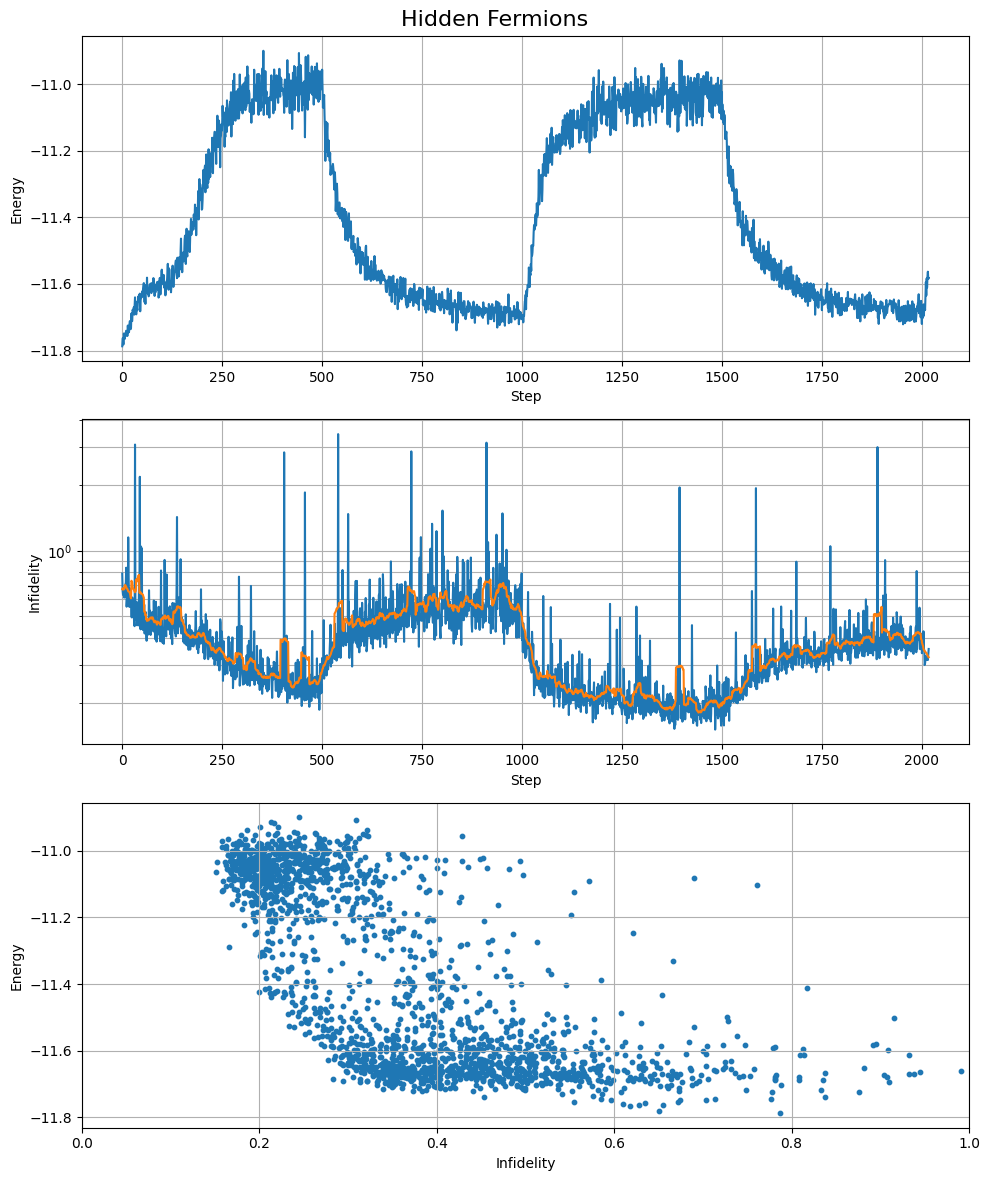

In [1]:
import json
import os
import time
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from IPython.display import clear_output

start_at = 0

logfile = "Switching_4x4_7_7_pbc_Infidelity_SR_Energy_SR_hf"
plot_title ="Hidden Fermions"
last_mtime = 0

plt.ion()  # interactive mode

lastc = 0
first = True
for _ in range(1):
    try:
        mtime = os.path.getmtime(logfile+str(lastc)+".log")
        if first:
            first = False
        else:
            time.sleep(300)
        if True:  # mtime != last_mtime:
            last_mtime = mtime
            
            all_infid_steps = []
            all_infid_mean = []
            all_energy_steps = []
            all_energy_mean = []

            step_offset = None

            for c in range(0, 100):
                try:
                    with open(logfile + str(c) + ".log", 'r') as f:
                        data = json.load(f)
                    print(f"Loaded {logfile + str(c) + '.log'}")
                    steps = data['Infidelity']['iters']
                    try:
                        energy = data['energy']
                    except KeyError:
                        energy = data['Energy']
                    energy_steps = energy['iters']
                    if step_offset is None:
                        step_offset = 0
                    else:
                        if len(all_infid_steps) > 0:
                            step_offset = max(all_infid_steps) - min(steps)
                    
                    all_infid_steps.extend([s + step_offset for s in steps])
                    all_infid_mean.extend(data['Infidelity']['Mean'])

                    all_energy_steps.extend([s + step_offset for s in energy_steps])
                    all_energy_mean.extend(energy['Mean']['real'])

                    # step_offset += max(steps) + 1
                    lastc = c

                except json.JSONDecodeError:
                    continue
                except FileNotFoundError:
                    break
                    pass
                
            import numpy as np

            mask = [x is not None for x in all_infid_mean]

            all_infid_mean = np.array(
                [x for x in all_infid_mean if x is not None],
                dtype=float
            )[start_at:]

            all_infid_steps = np.array(all_infid_steps)[mask][start_at:]

            all_energy_mean = np.array(
                [x for x in all_energy_mean if x is not None],
                dtype=float
            )[start_at:]
            all_energy_steps = np.array(
                [x for x in all_energy_steps if x is not None],
                dtype=float
            )[start_at:]
            

            clear_output(wait=True)

            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
            fig.suptitle(plot_title, fontsize=16)

            ax1.plot(all_infid_steps, all_energy_mean)
            ax1.set_xlabel("Step")
            ax1.set_ylabel("Energy")
            ax1.grid(True)

            ax2.plot(all_infid_steps, all_infid_mean)
            ax2.set_yscale('log')
            ax2.set_xlabel("Step")
            ax2.set_ylabel("Infidelity")
            window_size = 20
            # all_infid_mean = np.array(all_infid_mean, dtype=float)
            infid_mean_smooth = uniform_filter1d(all_infid_mean, size=window_size)
            ax2.plot(all_infid_steps, infid_mean_smooth)

            ax2.grid(True, which='both')
            
            ax3.scatter(all_infid_mean, all_energy_mean, s=10)
            ax3.set_xlabel("Infidelity")
            ax3.set_ylabel("Energy")
            ax3.set_xlim(left=0, right=1.0)
            # ax3.set_xscale("log")
            ax3.grid(True)

            plt.tight_layout()
            plt.show()

    except KeyboardInterrupt:
    
        print("Stopped.")
        break


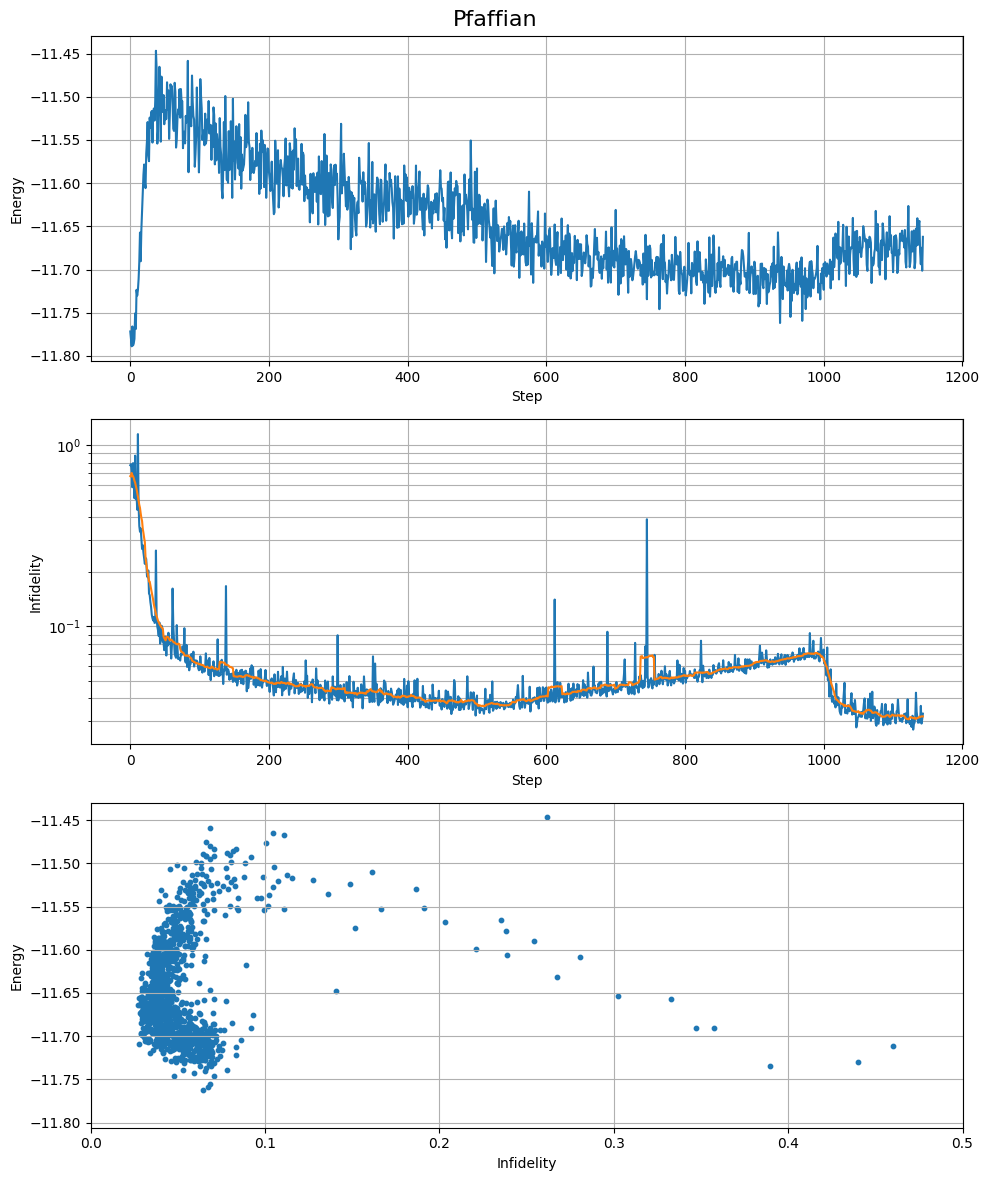

In [2]:
import json
import os
import time
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from IPython.display import clear_output

start_at = 0

logfile = "Switching_4x4_7_7_pbc_Infidelity_SR_Energy_SR_pf"
plot_title ="Pfaffian"
last_mtime = 0

plt.ion()  # interactive mode

lastc = 0
first = True
for _ in range(1):
    try:
        mtime = os.path.getmtime(logfile+str(lastc)+".log")
        if first:
            first = False
        else:
            time.sleep(300)
        if True:  # mtime != last_mtime:
            last_mtime = mtime
            
            all_infid_steps = []
            all_infid_mean = []
            all_energy_steps = []
            all_energy_mean = []

            step_offset = None

            for c in range(0, 100):
                try:
                    with open(logfile + str(c) + ".log", 'r') as f:
                        data = json.load(f)
                    print(f"Loaded {logfile + str(c) + '.log'}")
                    steps = data['Infidelity']['iters']
                    try:
                        energy = data['energy']
                    except KeyError:
                        energy = data['Energy']
                    energy_steps = energy['iters']
                    if step_offset is None:
                        step_offset = 0
                    else:
                        if len(all_infid_steps) > 0:
                            step_offset = max(all_infid_steps) - min(steps)
                    
                    all_infid_steps.extend([s + step_offset for s in steps])
                    all_infid_mean.extend(data['Infidelity']['Mean'])

                    all_energy_steps.extend([s + step_offset for s in energy_steps])
                    all_energy_mean.extend(energy['Mean']['real'])

                    # step_offset += max(steps) + 1
                    lastc = c

                except json.JSONDecodeError:
                    continue
                except FileNotFoundError:
                    break
                    pass
                
            import numpy as np

            mask = [x is not None for x in all_infid_mean]

            all_infid_mean = np.array(
                [x for x in all_infid_mean if x is not None],
                dtype=float
            )[start_at:]

            all_infid_steps = np.array(all_infid_steps)[mask][start_at:]

            all_energy_mean = np.array(
                [x for x in all_energy_mean if x is not None],
                dtype=float
            )[start_at:]
            all_energy_steps = np.array(
                [x for x in all_energy_steps if x is not None],
                dtype=float
            )[start_at:]
            

            clear_output(wait=True)

            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
            fig.suptitle(plot_title, fontsize=16)

            ax1.plot(all_infid_steps, all_energy_mean)
            ax1.set_xlabel("Step")
            ax1.set_ylabel("Energy")
            ax1.grid(True)

            ax2.plot(all_infid_steps, all_infid_mean)
            ax2.set_yscale('log')
            ax2.set_xlabel("Step")
            ax2.set_ylabel("Infidelity")
            window_size = 20
            # all_infid_mean = np.array(all_infid_mean, dtype=float)
            infid_mean_smooth = uniform_filter1d(all_infid_mean, size=window_size)
            ax2.plot(all_infid_steps, infid_mean_smooth)

            ax2.grid(True, which='both')
            
            ax3.scatter(all_infid_mean, all_energy_mean, s=10)
            ax3.set_xlabel("Infidelity")
            ax3.set_ylabel("Energy")
            ax3.set_xlim(left=0, right=0.5)
            # ax3.set_xscale("log")
            ax3.grid(True)

            plt.tight_layout()
            plt.show()

    except KeyboardInterrupt:
    
        print("Stopped.")
        break
